In [26]:
import pybaseball
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az

In [27]:
from pybaseball import batting_stats

In [28]:
data = batting_stats(2020,2021)
data['Team']

31     - - -
5        WSN
15       SDP
3        PHI
50       CLE
       ...  
233      DET
256      BOS
252      KCR
253      KCR
267    - - -
Name: Team, Length: 274, dtype: str

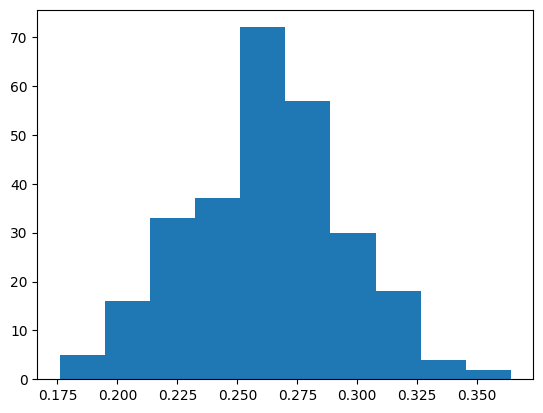

In [29]:
plt.hist(data['AVG'])
plt.show()

In [86]:
import pandas as pd
mat = data[['Season','AVG']]
mat.sort_values(by=['Season'],inplace=True,ascending=True)
mat

,Season,AVG
267,2020,0.232
129,2020,0.303
137,2020,0.262
169,2020,0.225
190,2020,0.250
...,...,...
85,2021,0.298
37,2021,0.294
42,2021,0.271
21,2021,0.257


In [87]:
X = mat['Season']
y = mat['AVG']
X

267    2020
129    2020
137    2020
169    2020
190    2020
       ... 
85     2021
37     2021
42     2021
21     2021
31     2021
Name: Season, Length: 274, dtype: int64

In [30]:
data_2 = batting_stats(2019,2020)


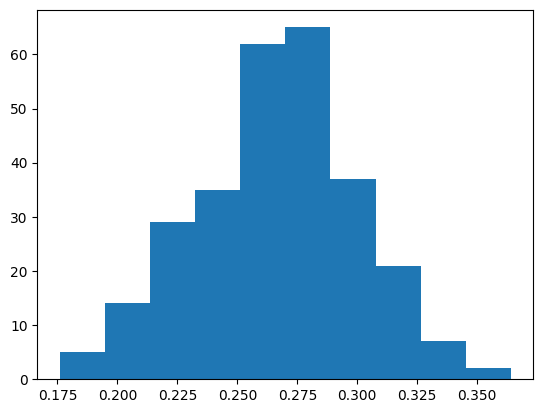

In [31]:
plt.hist(data_2['AVG'])
plt.show()

In [37]:
np.log10(data['AVG'].mean())


np.float64(-0.5803456900066666)

In [38]:
np.log10(data_2['AVG'].mean())

np.float64(-0.5739940328837199)

In [39]:
!uv add pymc

Resolved 141 packages in 858ms                                       
Prepared 7 packages in 5.86s                                             
Installed 22 packages in 40ms                               
 + arviz==0.23.4
 + cachetools==6.2.6
 + cloudpickle==3.1.2
 + cons==0.4.7
 + etuples==0.3.10
 + filelock==3.25.0
 + h5netcdf==1.8.1
 + h5py==3.16.0
 + llvmlite==0.46.0
 + logical-unification==0.4.7
 + markdown-it-py==4.0.0
 + mdurl==0.1.2
 + minikanren==1.0.5
 + multipledispatch==1.0.0
 + numba==0.64.0
 + pymc==5.28.1
 + pytensor==2.38.2
 + rich==14.3.3
 + threadpoolctl==3.6.0
 + toolz==1.1.0
 + xarray==2026.2.0
 + xarray-einstats==0.10.0


In [41]:
y = data['AVG']
y.head()

31    0.328
5     0.313
15    0.282
3     0.309
50    0.266
Name: AVG, dtype: float64

In [89]:
import pymc as pm 
basic_model = pm.Model()

with basic_model:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1)
    mu = alpha + beta * X 
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed = y)
    idata = pm.sample(threads=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 234 seconds.
There were 31 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

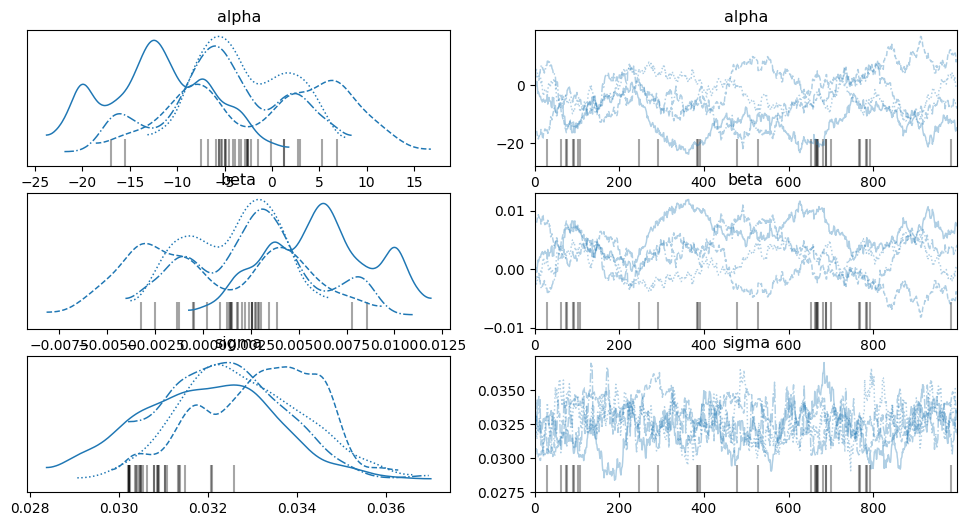

In [90]:
import arviz as az
az.plot_trace(idata);

In [30]:
data_m0 = data[['Age','SLG','Barrel%','OBP','HardHit%']]
# normalizing the age value
ages_normal = (data['Age'] - data['Age'].mean()) / data['Age'].std()
data_m0['Age'] = ages_normal
data_m0.head()

,Age,SLG,Barrel%,OBP,HardHit%
31,-0.080183,0.536,0.074,0.375,0.462
5,-1.792138,0.534,0.133,0.465,0.527
15,-1.792138,0.611,0.213,0.364,0.556
3,-0.080183,0.615,0.181,0.429,0.497
50,-0.080183,0.538,0.111,0.355,0.423


In [31]:
# targetting batting avg
y = data['AVG']
y.head()

31    0.328
5     0.313
15    0.282
3     0.309
50    0.266
Name: AVG, dtype: float64

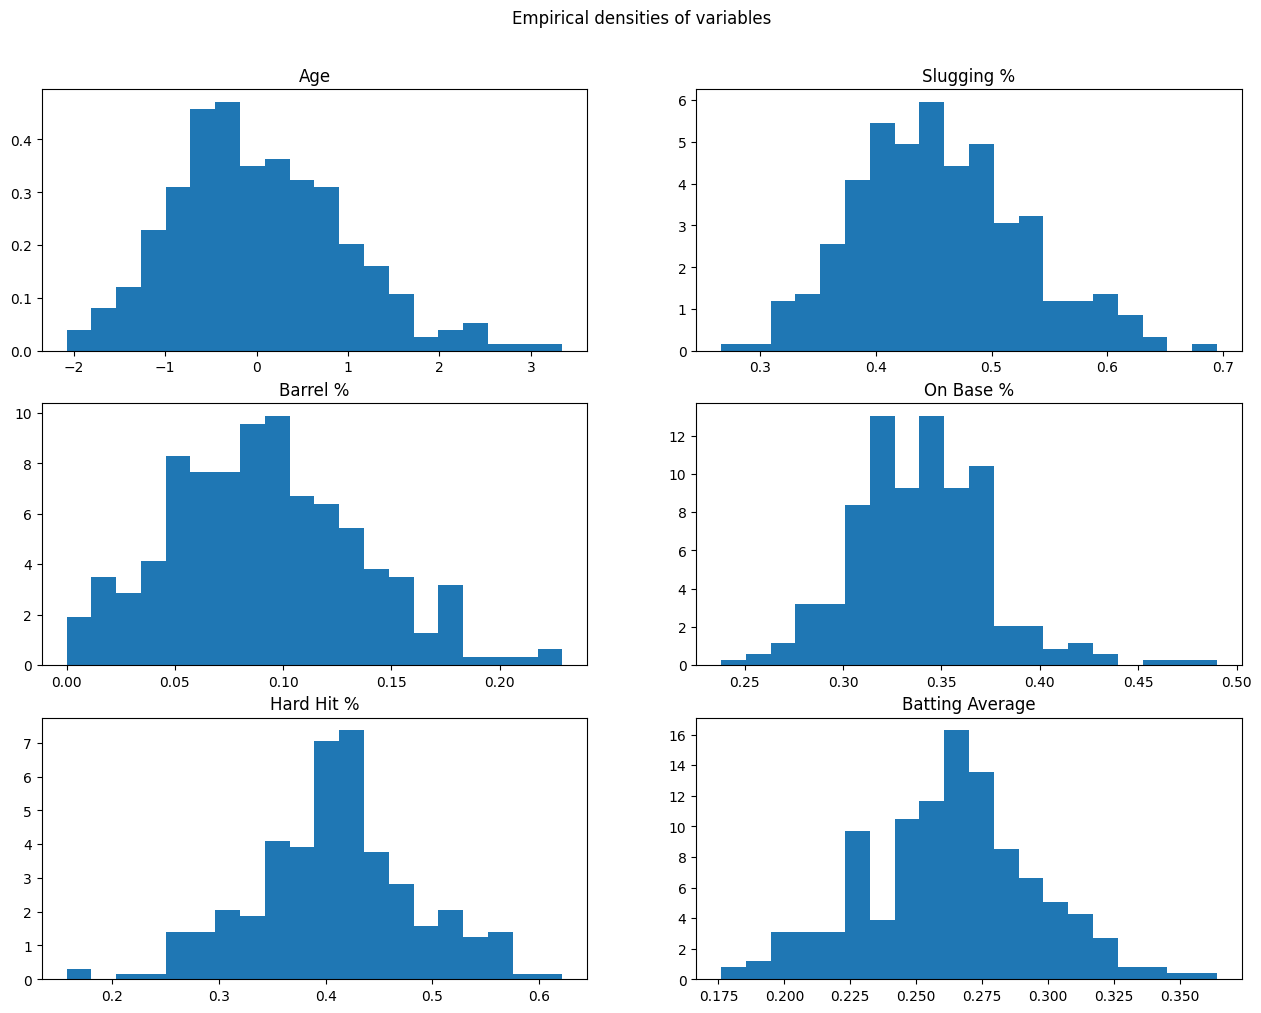

In [86]:
fig, ((ax1,ax2),(ax3,ax4),(ax5,ax6)) = plt.subplots(3,2,figsize=(8,6))
fig.suptitle("Empirical densities of variables")
fig.set_figwidth(15)
fig.set_figheight(10)
ax1.hist(data_m0['Age'],bins=20,density=True)
ax1.set_title('Age')
ax2.hist(data_m0['SLG'],bins=20,density=True)
ax2.set_title('Slugging %')
ax3.hist(data_m0['Barrel%'],bins=20,density=True)
ax3.set_title('Barrel %')
ax4.hist(data_m0['OBP'],bins=20,density=True)
ax4.set_title('On Base %')
ax5.hist(data_m0['HardHit%'],bins=20,density=True)
ax5.set_title('Hard Hit %')
ax6.hist(y,bins=20,density=True)
ax6.set_title('Batting Average')
plt.subplots_adjust(0.1,0.01,top=0.9)
    
    
    